# 🤖 Model Experiments - Telco Customer Churn

**Objective:** Train, evaluate, and compare different machine learning models for churn prediction.

**Models to Test:**
- Logistic Regression (Baseline)
- Decision Tree
- Random Forest
- Gradient Boosting (XGBoost)
- Support Vector Machine (SVM)
- Neural Network

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Additional tools
from sklearn.model_selection import cross_val_score, GridSearchCV
import time

pd.set_option('display.max_columns', None)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Processed Data

In [2]:
# Load train and test sets
print("📥 Loading processed datasets...")

X_train = pd.read_csv('../artifacts/data/X_train.csv')
X_test = pd.read_csv('../artifacts/data/X_test.csv')
y_train = pd.read_csv('../artifacts/data/y_train.csv')['Churn'].values
y_test = pd.read_csv('../artifacts/data/y_test.csv')['Churn'].values

print(f"\n✅ Data loaded successfully!")
print(f"   Training: {X_train.shape}")
print(f"   Test: {X_test.shape}")
print(f"   Features: {X_train.shape[1]}")

📥 Loading processed datasets...

✅ Data loaded successfully!
   Training: (5634, 42)
   Test: (1409, 42)
   Features: 42


In [3]:
# Check class distribution
print("\n📊 Class Distribution:")
print(f"Training - Churn: {y_train.mean()*100:.2f}%, No Churn: {(1-y_train.mean())*100:.2f}%")
print(f"Test - Churn: {y_test.mean()*100:.2f}%, No Churn: {(1-y_test.mean())*100:.2f}%")


📊 Class Distribution:
Training - Churn: 26.54%, No Churn: 73.46%
Test - Churn: 26.54%, No Churn: 73.46%


## 3. Define Evaluation Functions

In [4]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a model, return metrics
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Probabilities (if available)
    try:
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_proba_test = None
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_pred_train),
        'Test_Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1_Score': f1_score(y_test, y_pred_test),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba_test) if y_pred_proba_test is not None else np.nan,
        'Training_Time': train_time
    }
    
    # Print results
    print(f"\n✅ Training completed in {train_time:.2f} seconds")
    print(f"\n📊 Performance Metrics:")
    print(f"   Train Accuracy: {metrics['Train_Accuracy']:.4f}")
    print(f"   Test Accuracy:  {metrics['Test_Accuracy']:.4f}")
    print(f"   Precision:      {metrics['Precision']:.4f}")
    print(f"   Recall:         {metrics['Recall']:.4f}")
    print(f"   F1-Score:       {metrics['F1_Score']:.4f}")
    print(f"   ROC-AUC:        {metrics['ROC_AUC']:.4f}" if not np.isnan(metrics['ROC_AUC']) else "   ROC-AUC: N/A")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    print(f"\n📈 Confusion Matrix:")
    print(cm)
    
    return metrics, model, y_pred_test, y_pred_proba_test, cm

In [5]:
def plot_confusion_matrix(cm, model_name):
    """
    Plot confusion matrix heatmap
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

## 4. Train Baseline Models

In [6]:
# Initialize results storage
results = []
models_dict = {}
predictions_dict = {}

### 4.1 Logistic Regression


Training: Logistic Regression

✅ Training completed in 0.07 seconds

📊 Performance Metrics:
   Train Accuracy: 0.8111
   Test Accuracy:  0.8055
   Precision:      0.6689
   Recall:         0.5294
   F1-Score:       0.5910
   ROC-AUC:        0.8463

📈 Confusion Matrix:
[[937  98]
 [176 198]]


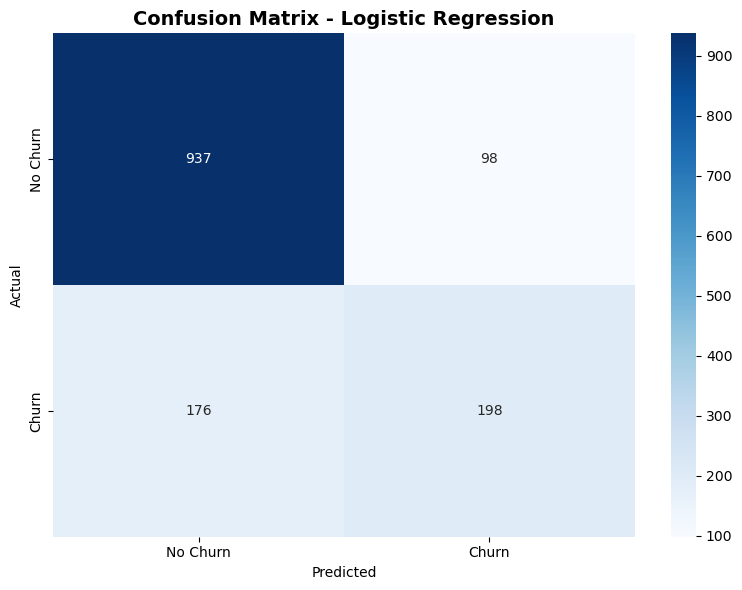

In [7]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_metrics, lr_trained, lr_pred, lr_proba, lr_cm = evaluate_model(
    lr_model, X_train, X_test, y_train, y_test, 'Logistic Regression'
)

results.append(lr_metrics)
models_dict['Logistic Regression'] = lr_trained
predictions_dict['Logistic Regression'] = (lr_pred, lr_proba)

plot_confusion_matrix(lr_cm, 'Logistic Regression')

### 4.2 Decision Tree


Training: Decision Tree

✅ Training completed in 0.03 seconds

📊 Performance Metrics:
   Train Accuracy: 0.8552
   Test Accuracy:  0.7686
   Precision:      0.5667
   Recall:         0.5455
   F1-Score:       0.5559
   ROC-AUC:        0.7880

📈 Confusion Matrix:
[[879 156]
 [170 204]]


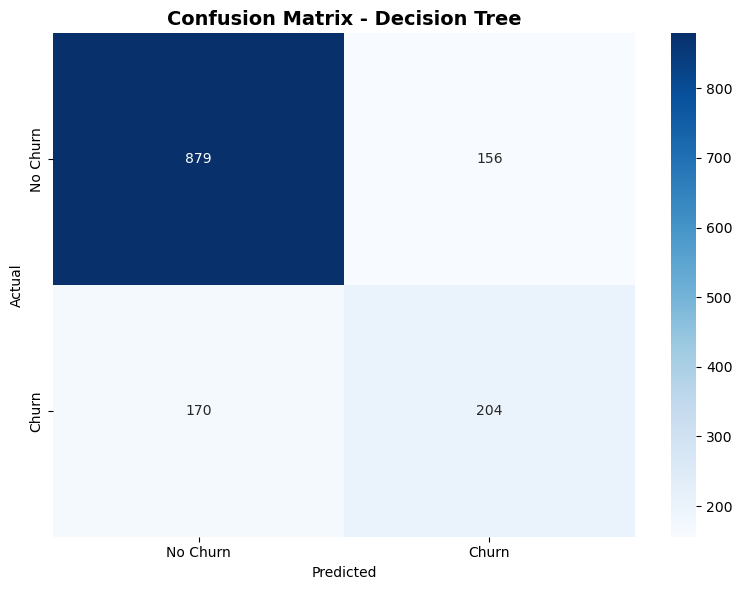

In [8]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20)
dt_metrics, dt_trained, dt_pred, dt_proba, dt_cm = evaluate_model(
    dt_model, X_train, X_test, y_train, y_test, 'Decision Tree'
)

results.append(dt_metrics)
models_dict['Decision Tree'] = dt_trained
predictions_dict['Decision Tree'] = (dt_pred, dt_proba)

plot_confusion_matrix(dt_cm, 'Decision Tree')

### 4.3 Random Forest


Training: Random Forest

✅ Training completed in 0.20 seconds

📊 Performance Metrics:
   Train Accuracy: 0.9980
   Test Accuracy:  0.7814
   Precision:      0.6086
   Recall:         0.4947
   F1-Score:       0.5457
   ROC-AUC:        0.8244

📈 Confusion Matrix:
[[916 119]
 [189 185]]


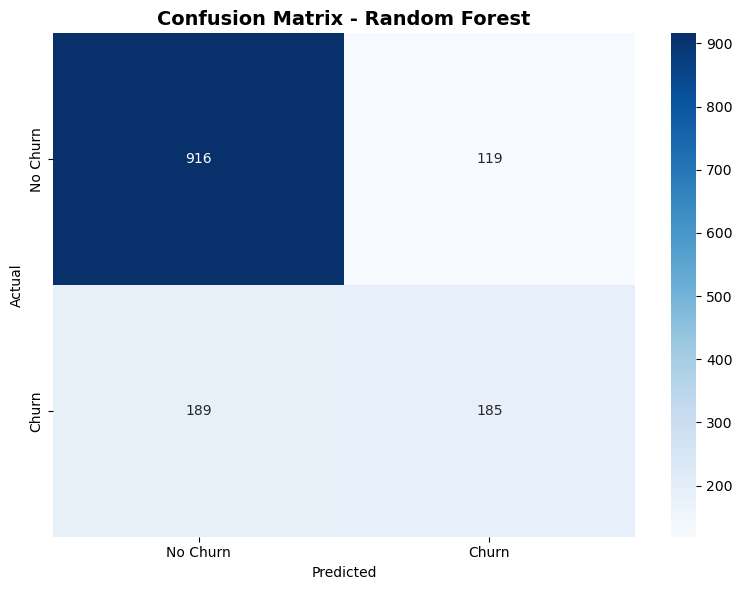

In [9]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_metrics, rf_trained, rf_pred, rf_proba, rf_cm = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, 'Random Forest'
)

results.append(rf_metrics)
models_dict['Random Forest'] = rf_trained
predictions_dict['Random Forest'] = (rf_pred, rf_proba)

plot_confusion_matrix(rf_cm, 'Random Forest')

### 4.4 Gradient Boosting


Training: Gradient Boosting

✅ Training completed in 1.16 seconds

📊 Performance Metrics:
   Train Accuracy: 0.8298
   Test Accuracy:  0.8006
   Precision:      0.6566
   Recall:         0.5214
   F1-Score:       0.5812
   ROC-AUC:        0.8451

📈 Confusion Matrix:
[[933 102]
 [179 195]]


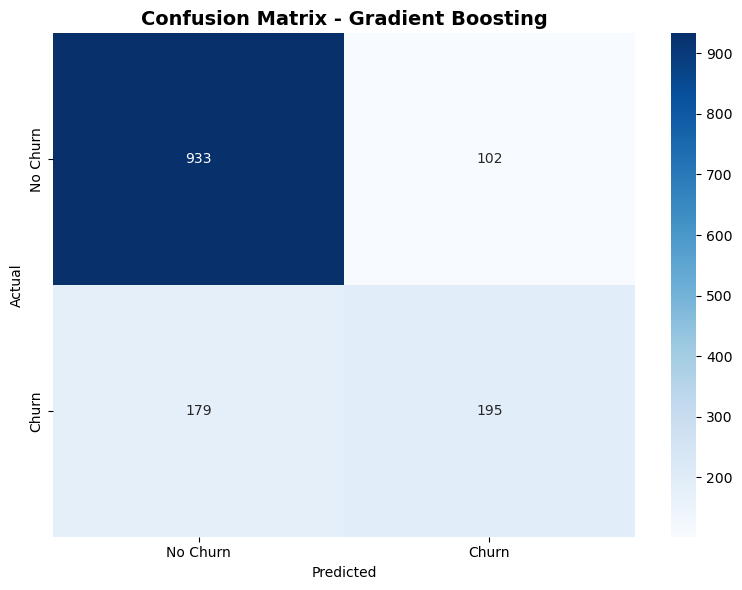

In [10]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
gb_metrics, gb_trained, gb_pred, gb_proba, gb_cm = evaluate_model(
    gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting'
)

results.append(gb_metrics)
models_dict['Gradient Boosting'] = gb_trained
predictions_dict['Gradient Boosting'] = (gb_pred, gb_proba)

plot_confusion_matrix(gb_cm, 'Gradient Boosting')

### 4.5 Support Vector Machine

⚠️ Training SVM on sample (slower on full dataset)...

Training: SVM

✅ Training completed in 4.39 seconds

📊 Performance Metrics:
   Train Accuracy: 0.8177
   Test Accuracy:  0.7892
   Precision:      0.6410
   Recall:         0.4679
   F1-Score:       0.5410
   ROC-AUC:        0.8003

📈 Confusion Matrix:
[[937  98]
 [199 175]]


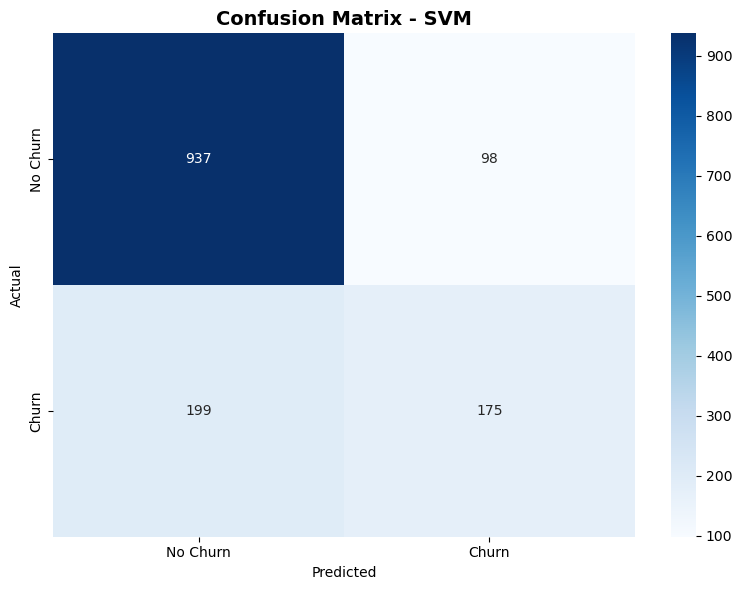

In [11]:
# SVM (use subset for faster training)
print("⚠️ Training SVM on sample (slower on full dataset)...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_metrics, svm_trained, svm_pred, svm_proba, svm_cm = evaluate_model(
    svm_model, X_train, X_test, y_train, y_test, 'SVM'
)

results.append(svm_metrics)
models_dict['SVM'] = svm_trained
predictions_dict['SVM'] = (svm_pred, svm_proba)

plot_confusion_matrix(svm_cm, 'SVM')

## 5. Model Comparison

In [12]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1_Score', ascending=False)

print("\n" + "="*80)
print("📊 MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1_Score']
print(f"\n🏆 Best Model: {best_model_name} (F1-Score: {best_f1:.4f})")


📊 MODEL COMPARISON
              Model  Train_Accuracy  Test_Accuracy  Precision   Recall  F1_Score  ROC_AUC  Training_Time
Logistic Regression        0.811147       0.805536   0.668919 0.529412  0.591045 0.846299       0.072134
  Gradient Boosting        0.829783       0.800568   0.656566 0.521390  0.581222 0.845059       1.160933
      Decision Tree        0.855165       0.768630   0.566667 0.545455  0.555858 0.788026       0.034084
      Random Forest        0.998048       0.781405   0.608553 0.494652  0.545723 0.824387       0.197106
                SVM        0.817714       0.789212   0.641026 0.467914  0.540958 0.800287       4.389500

🏆 Best Model: Logistic Regression (F1-Score: 0.5910)


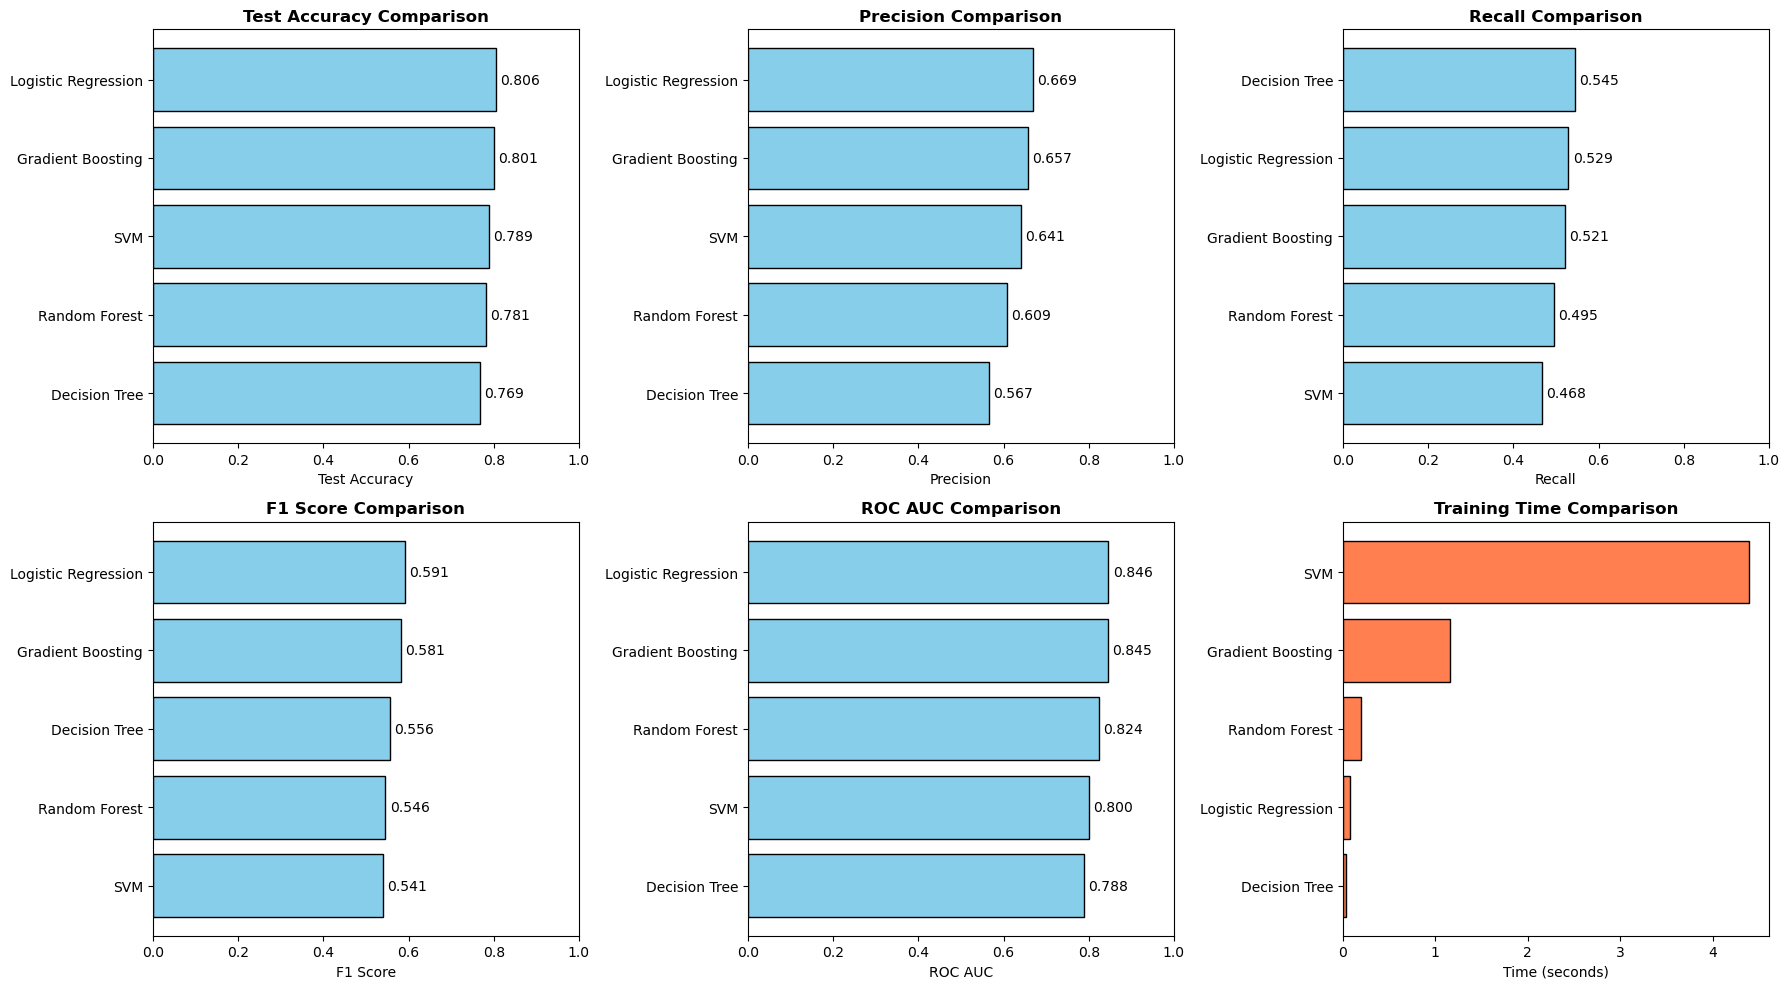

In [13]:
# Visualize model comparison
metrics_to_plot = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    data = results_df.sort_values(metric, ascending=True)
    axes[i].barh(data['Model'], data[metric], color='skyblue', edgecolor='black')
    axes[i].set_xlabel(metric.replace('_', ' '))
    axes[i].set_title(f'{metric.replace("_", " ")} Comparison', fontweight='bold')
    axes[i].set_xlim(0, 1)
    
    # Add value labels
    for j, v in enumerate(data[metric]):
        if not np.isnan(v):
            axes[i].text(v + 0.01, j, f'{v:.3f}', va='center')

# Training time comparison
data = results_df.sort_values('Training_Time', ascending=True)
axes[5].barh(data['Model'], data['Training_Time'], color='coral', edgecolor='black')
axes[5].set_xlabel('Time (seconds)')
axes[5].set_title('Training Time Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. ROC Curves Comparison

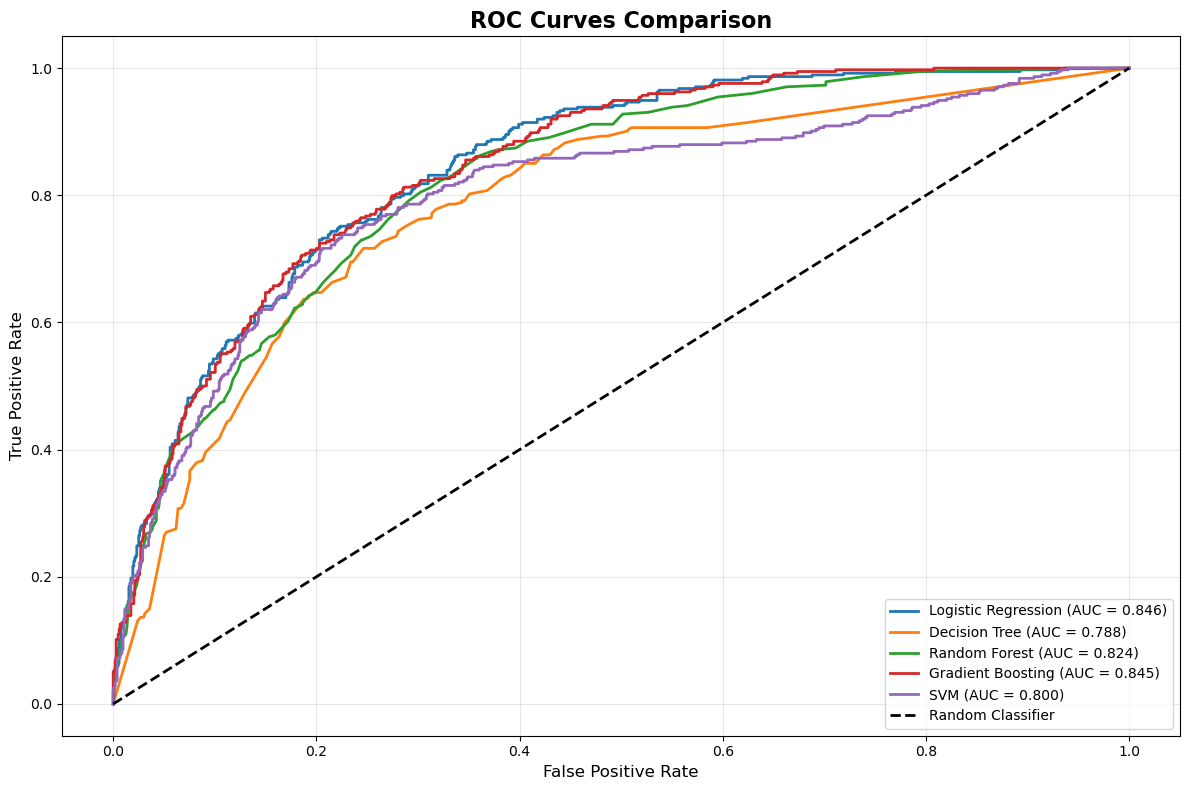

In [14]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name, (pred, proba) in predictions_dict.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance (Best Model)

In [15]:
# Get feature importance from best tree-based model
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    best_model = models_dict[best_model_name]
    
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\n📊 Top 20 Features ({best_model_name}):")
    print(feature_importance.head(20).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(12, 8))
    feature_importance.head(20).sort_values('Importance').plot(
        kind='barh', x='Feature', y='Importance', legend=False, color='skyblue', edgecolor='black'
    )
    plt.title(f'Top 20 Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️ Feature importance not available for {best_model_name}")


⚠️ Feature importance not available for Logistic Regression


## 8. Save Best Model

In [16]:
import pickle
import os

# Create directory
os.makedirs('../artifacts/models', exist_ok=True)

# Save best model
best_model = models_dict[best_model_name]
model_path = '../artifacts/models/best_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n✅ Best model saved: {model_path}")
print(f"   Model: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")

# Save all results
results_df.to_csv('../artifacts/models/model_comparison.csv', index=False)
print("\n✅ Model comparison saved: ../artifacts/models/model_comparison.csv")


✅ Best model saved: ../artifacts/models/best_model.pkl
   Model: Logistic Regression
   F1-Score: 0.5910

✅ Model comparison saved: ../artifacts/models/model_comparison.csv


## 9. Summary & Recommendations

In [17]:
print("\n" + "="*80)
print("📋 MODEL EXPERIMENTS SUMMARY")
print("="*80)

print("\n✅ MODELS TRAINED:")
for model_name in models_dict.keys():
    print(f"   • {model_name}")

print("\n🏆 BEST MODEL:")
best_row = results_df.iloc[0]
print(f"   Model: {best_row['Model']}")
print(f"   Accuracy: {best_row['Test_Accuracy']:.4f}")
print(f"   Precision: {best_row['Precision']:.4f}")
print(f"   Recall: {best_row['Recall']:.4f}")
print(f"   F1-Score: {best_row['F1_Score']:.4f}")
print(f"   ROC-AUC: {best_row['ROC_AUC']:.4f}")

print("\n💡 RECOMMENDATIONS:")
print("   1. Consider hyperparameter tuning for the best model")
print("   2. Try ensemble methods (stacking/voting)")
print("   3. Handle class imbalance with SMOTE if needed")
print("   4. Feature selection to reduce model complexity")
print("   5. Cross-validation for more robust evaluation")

print("\n🎯 NEXT STEPS:")
print("   • Implement best model in production pipeline")
print("   • Set up MLflow tracking for experiment management")
print("   • Deploy model for real-time inference")
print("   • Monitor model performance in production")

print("\n" + "="*80)


📋 MODEL EXPERIMENTS SUMMARY

✅ MODELS TRAINED:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • SVM

🏆 BEST MODEL:
   Model: Logistic Regression
   Accuracy: 0.8055
   Precision: 0.6689
   Recall: 0.5294
   F1-Score: 0.5910
   ROC-AUC: 0.8463

💡 RECOMMENDATIONS:
   1. Consider hyperparameter tuning for the best model
   2. Try ensemble methods (stacking/voting)
   3. Handle class imbalance with SMOTE if needed
   4. Feature selection to reduce model complexity
   5. Cross-validation for more robust evaluation

🎯 NEXT STEPS:
   • Implement best model in production pipeline
   • Set up MLflow tracking for experiment management
   • Deploy model for real-time inference
   • Monitor model performance in production

